In [3]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [6]:
# 1. make some fake temprature data
temperatures = np.sin(np.arange(500)* 0.1) * 10 +25      # Wiggly temp data (like a zigzag line!)
df = pd.DataFrame({"temp": temperatures})

In [8]:
# 2. Prepare data for LSTM
look_back =     3# Use last 3 days to predict next day
x = []
y = []
for i in range(len(df) - look_back):
    x.append(df["temp"].iloc[i:i+look_back].values)
    y.append(df["temp"].iloc[i+look_back])
x, y = np.array(x), np.array (y)
x = x.reshape((x.shape[0], x.shape[1],1))    # Reshape for LSTM (samples, timesteps, features)

In [14]:
# 3. Build the LSTM model
model = Sequential()
model.add(LSTM(20, input_shape=(look_back, 1)))
model.add(Dense(1))

model.compile(optimizer = 'Adam', loss='mean_squared_error')

C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
# 4. Train the model
model.fit(x, y, epochs = 500, batch_size=3)         # Watch data, try to guess correct answer 500 times

In [17]:
# 5. Predict tomorrow's temperature
tommrow = model.predict(x[-1].reshape(1, look_back, 1))
print(f"predicted temperature for tommrow: {tommrow[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
predicted temperature for tommrow: 0.04


Epoch 1/50


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 758.0710
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 739.7360 
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 716.9943 
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 688.7357 
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 657.6608 
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 619.7140 
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 571.7070 
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 518.7109 
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 469.1740 
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 438.3742 
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 418.3458 
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 397.1429 
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 378.2126 
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 360.9183 
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - lo

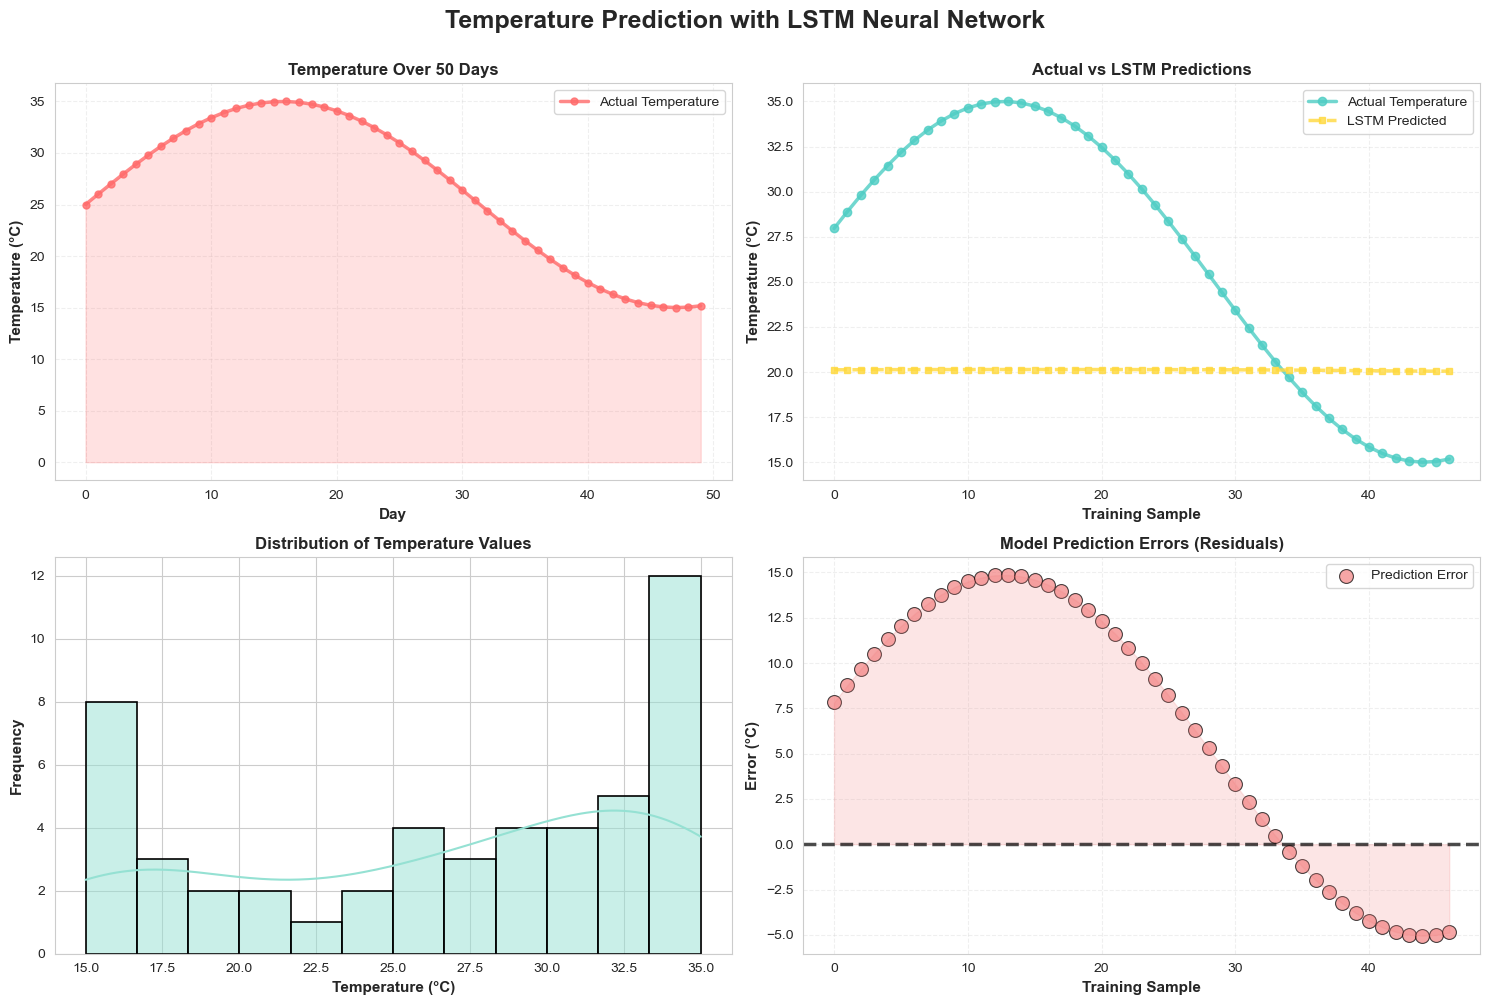


TEMPERATURE PREDICTION SUMMARY
Average temperature: 26.53°C
Min temperature: 15.00°C
Max temperature: 35.00°C
Temperature std deviation: 7.10°C

LSTM Model Performance:
  Mean Absolute Error: 8.4416°C
  Max Error: 14.8582°C

Predicted temperature for tomorrow: 20.05°C


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Set seaborn style for beautiful plots
sns.set_style("whitegrid")
sns.set_palette("husl")

# 1. Make some fake temperature data
temperatures = np.sin(np.arange(50) * 0.1) * 10 + 25   # Wiggly temp data (like a zigzag line!)
df = pd.DataFrame({"temp": temperatures})

# 2. Prepare data for LSTM
look_back = 3   # Use last 3 days to predict next day
X = []
y = []
for i in range(len(df) - look_back):
    X.append(df["temp"].iloc[i:i+look_back].values)
    y.append(df["temp"].iloc[i+look_back])
X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))   # Reshape for LSTM (samples, timesteps, features)

# 3. Build the LSTM model
model = Sequential()
model.add(LSTM(20, input_shape=(look_back, 1)))      # 20 memory cells, remember patterns
model.add(Dense(1))                                  # One number out: the temp prediction

model.compile(optimizer='adam', loss='mean_squared_error')  # Set up learning rules!

# 4. Train the model
model.fit(X, y, epochs=50, batch_size=3)    # Watch data, try to guess correct answer 50 times

# 5. Predict tomorrow's temperature
tomorrow = model.predict(X[-1].reshape(1, look_back, 1))
print(f"Predicted temperature for tomorrow: {tomorrow[0][0]:.2f}")

# 6. Get predictions for all training data
all_predictions = model.predict(X)

# 7. Create beautiful visualizations with matplotlib and seaborn
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Temperature Prediction with LSTM Neural Network', fontsize=18, fontweight='bold', y=1.00)

# Plot 1: Original temperature data over time
axes[0, 0].plot(df.index, df['temp'], marker='o', linewidth=2.5, markersize=5, 
                color='#FF6B6B', label='Actual Temperature', alpha=0.8)
axes[0, 0].fill_between(df.index, df['temp'], alpha=0.2, color='#FF6B6B')
axes[0, 0].set_xlabel('Day', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Temperature Over 50 Days', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='best', fontsize=10)
axes[0, 0].grid(True, alpha=0.3, linestyle='--')

# Plot 2: Actual vs Predicted temperatures
axes[0, 1].plot(range(len(y)), y, marker='o', linewidth=2.5, markersize=6, 
                label='Actual Temperature', color='#4ECDC4', alpha=0.8)
axes[0, 1].plot(range(len(all_predictions)), all_predictions, marker='s', linewidth=2.5, 
                markersize=5, label='LSTM Predicted', color='#FFD93D', linestyle='--', alpha=0.8)
axes[0, 1].set_xlabel('Training Sample', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Actual vs LSTM Predictions', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='best', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, linestyle='--')

# Plot 3: Temperature distribution with seaborn
sns.histplot(data=df, x='temp', bins=12, kde=True, ax=axes[1, 0], 
             color='#95E1D3', edgecolor='black', linewidth=1.2)
axes[1, 0].set_title('Distribution of Temperature Values', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Temperature (°C)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')

# Plot 4: Prediction errors (residuals)
residuals = y - all_predictions.flatten()
axes[1, 1].scatter(range(len(residuals)), residuals, s=100, alpha=0.7, 
                   color='#F38181', edgecolors='black', linewidth=0.8, label='Prediction Error')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=2.5, alpha=0.7)
axes[1, 1].fill_between(range(len(residuals)), residuals, 0, alpha=0.2, color='#F38181')
axes[1, 1].set_xlabel('Training Sample', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Error (°C)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Model Prediction Errors (Residuals)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, linestyle='--')
axes[1, 1].legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

# 8. Print detailed summary statistics
print("\n" + "="*60)
print("TEMPERATURE PREDICTION SUMMARY")
print("="*60)
print(f"Average temperature: {df['temp'].mean():.2f}°C")
print(f"Min temperature: {df['temp'].min():.2f}°C")
print(f"Max temperature: {df['temp'].max():.2f}°C")
print(f"Temperature std deviation: {df['temp'].std():.2f}°C")
print(f"\nLSTM Model Performance:")
print(f"  Mean Absolute Error: {np.mean(np.abs(residuals)):.4f}°C")
print(f"  Max Error: {np.max(np.abs(residuals)):.4f}°C")
print(f"\nPredicted temperature for tomorrow: {tomorrow[0][0]:.2f}°C")
print("="*60)


In [18]:
# Bring in helpers to do math and build a smart brain!
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Make up some 'steps walked' daily numbers
steps = np.array([1000,1100,1150,1300,1200,1500,1400,1450,1350,1600,1550,1700,
                  1750,1800,1850,1700,1675,1600,1620,1650,1680,1700,1710,1720,1700])
df = pd.DataFrame({"steps": steps})

# 2. Turn the steps into 'questions and answers' for LSTM
look_back = 3 # Look at last 3 days each time
X, y = [], []
for i in range(len(df) - look_back):
    X.append(df['steps'].iloc[i:i+look_back].values)
    y.append(df['steps'].iloc[i+look_back])
X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1)) # LSTM needs this shape

# 3. Build the LSTM 'brain'
model = Sequential()
model.add(LSTM(16, input_shape=(look_back, 1))) # 16 tiny memory blocks
model.add(Dense(1)) # One answer: the predicted steps

model.compile(optimizer='adam', loss='mse') # 'adam' is the way to learn; 'mse' means less wrong

# 4. Teach our brain!
model.fit(X, y, epochs=50, batch_size=3) # Watch the story 50 times, 3 pieces each time

# 5. Use our brain to guess tomorrow
tomorrow = model.predict(X[-1].reshape(1, look_back, 1))
print("Tomorrow's steps might be:", int(tomorrow[0][0]))


Epoch 1/50


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 2585231.5000
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2585142.0000  
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2585051.7500  
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2584961.7500 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2584871.7500 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2584781.0000 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2584692.2500
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2584601.2500
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2584511.7500 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2584422.5000
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2584333.2500
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2584244.0000
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2584152.5000 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2584063.0000 
Epoch 15/50
8/8 ━━━━━━

Epoch 1/50


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2585435.7500
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2585346.2500 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2585251.0000
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2585017.7500
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2584885.0000 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2584761.2500 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2584637.7500 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2584515.7500 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2584393.0000 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2584270.5000 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2584150.5000 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2584031.2500 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2583911.2500 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2583793.7500
Epoch 15/50
8/8 ━━━━━━━━━━━

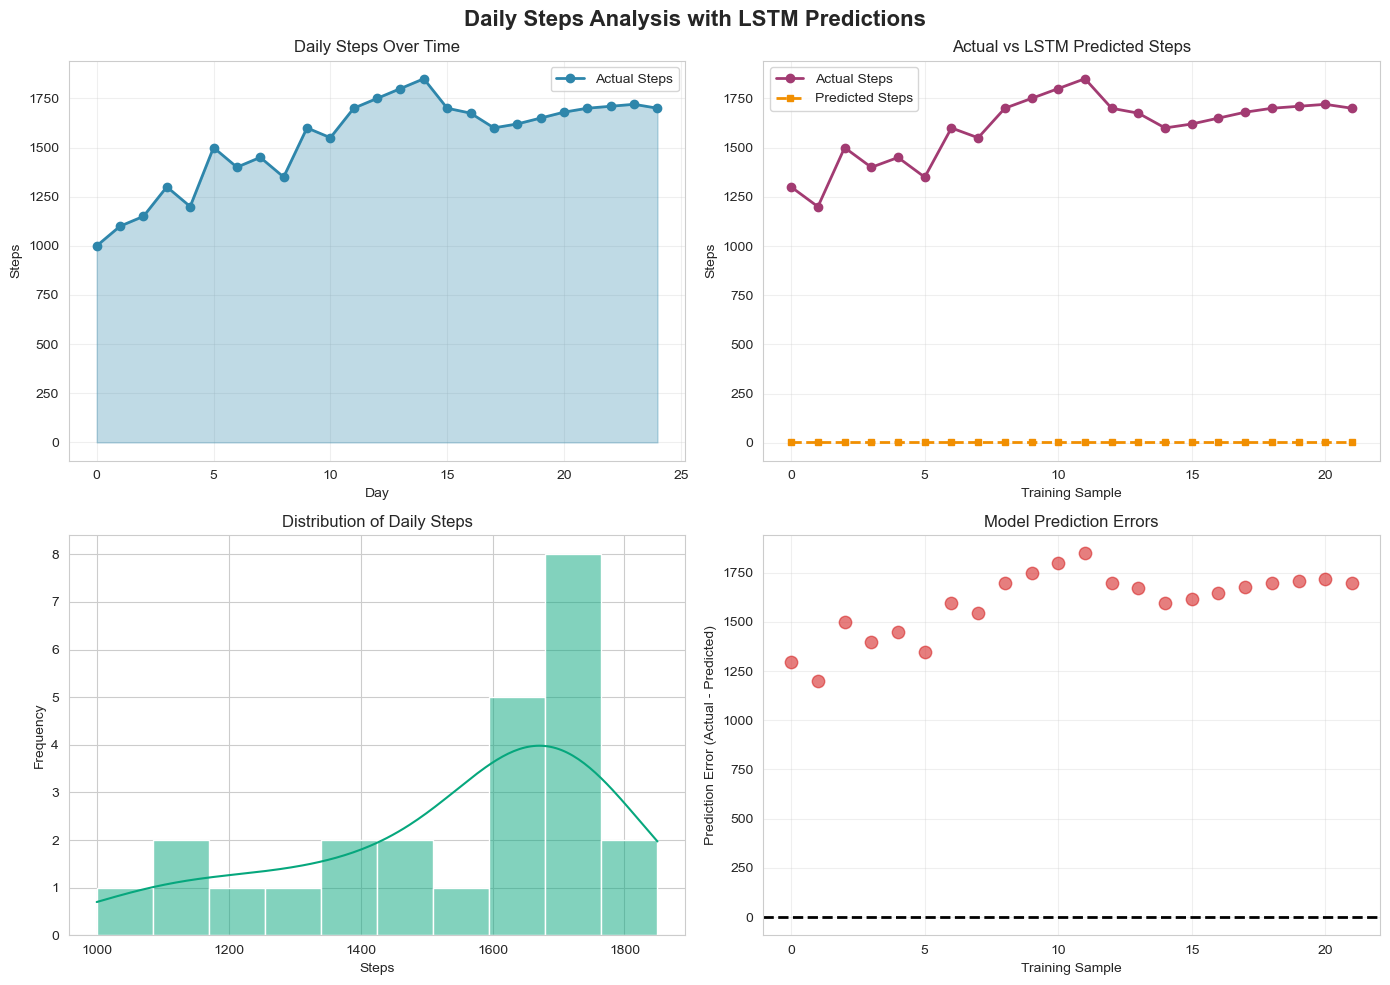


STEPS DATA SUMMARY
Average daily steps: 1538
Min steps: 1000
Max steps: 1850
Standard deviation: 234

Prediction for tomorrow: 2 steps


In [19]:
# Bring in helpers to do math and build a smart brain!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Set seaborn style for better-looking plots
sns.set_style("whitegrid")

# 1. Make up some 'steps walked' daily numbers
steps = np.array([1000,1100,1150,1300,1200,1500,1400,1450,1350,1600,1550,1700,
                  1750,1800,1850,1700,1675,1600,1620,1650,1680,1700,1710,1720,1700])
df = pd.DataFrame({"steps": steps})

# 2. Turn the steps into 'questions and answers' for LSTM
look_back = 3 # Look at last 3 days each time
X, y = [], []
for i in range(len(df) - look_back):
    X.append(df['steps'].iloc[i:i+look_back].values)
    y.append(df['steps'].iloc[i+look_back])
X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1)) # LSTM needs this shape

# 3. Build the LSTM 'brain'
model = Sequential()
model.add(LSTM(16, input_shape=(look_back, 1))) # 16 tiny memory blocks
model.add(Dense(1)) # One answer: the predicted steps

model.compile(optimizer='adam', loss='mse') # 'adam' is the way to learn; 'mse' means less wrong

# 4. Teach our brain!
model.fit(X, y, epochs=50, batch_size=3) # Watch the story 50 times, 3 pieces each time

# 5. Use our brain to guess tomorrow
tomorrow = model.predict(X[-1].reshape(1, look_back, 1))
print("Tomorrow's steps might be:", int(tomorrow[0][0]))

# 6. Get predictions for all training data to visualize
all_predictions = model.predict(X)

# 7. Create beautiful visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Daily Steps Analysis with LSTM Predictions', fontsize=16, fontweight='bold')

# Plot 1: Original steps over time
axes[0, 0].plot(df.index, df['steps'], marker='o', linewidth=2, markersize=6, 
                color='#2E86AB', label='Actual Steps')
axes[0, 0].fill_between(df.index, df['steps'], alpha=0.3, color='#2E86AB')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_ylabel('Steps')
axes[0, 0].set_title('Daily Steps Over Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted steps
axes[0, 1].plot(range(len(y)), y, marker='o', linewidth=2, markersize=6, 
                label='Actual Steps', color='#A23B72')
axes[0, 1].plot(range(len(all_predictions)), all_predictions, marker='s', linewidth=2, 
                markersize=5, label='Predicted Steps', color='#F18F01', linestyle='--')
axes[0, 1].set_xlabel('Training Sample')
axes[0, 1].set_ylabel('Steps')
axes[0, 1].set_title('Actual vs LSTM Predicted Steps')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Distribution of steps using seaborn
sns.histplot(data=df, x='steps', bins=10, kde=True, ax=axes[1, 0], color='#06A77D')
axes[1, 0].set_title('Distribution of Daily Steps')
axes[1, 0].set_xlabel('Steps')
axes[1, 0].set_ylabel('Frequency')

# Plot 4: Prediction error (residuals)
residuals = y - all_predictions.flatten()
axes[1, 1].scatter(range(len(residuals)), residuals, s=80, alpha=0.6, color='#D62828')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Training Sample')
axes[1, 1].set_ylabel('Prediction Error (Actual - Predicted)')
axes[1, 1].set_title('Model Prediction Errors')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("STEPS DATA SUMMARY")
print("="*50)
print(f"Average daily steps: {df['steps'].mean():.0f}")
print(f"Min steps: {df['steps'].min():.0f}")
print(f"Max steps: {df['steps'].max():.0f}")
print(f"Standard deviation: {df['steps'].std():.0f}")
print(f"\nPrediction for tomorrow: {int(tomorrow[0][0])} steps")
print("="*50)


In [2]:
# Bring in helpers to do math and build a smart brain!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [4]:
# Set seaborn style for better-looking plots
sns.set_style("whitegrid")

In [6]:
# 1. Make up some 'steps walked' daily numbers
steps = np.array([1000,1100,1150,1300,1200,1500,1400,1450,1350,1600,1550,1700,
                  1750,1800,1850,1700,1675,1600,1620,1650,1680,1700,1710,1720,1700])
df = pd.DataFrame({"steps": steps})

In [9]:
# 2. Turn the steps into 'questions and answers' for LSTM
look_back = 3     # Look at last 3 days each time
x,y = [],[]
for i in range(len(df) - look_back):
    x.append(df['steps'].iloc[i:i+look_back].values)
    y.append(df['steps'].iloc[i+look_back])
x, y = np.array(x), np.array(y)
x = x.reshape((x.shape[0], x.shape[1], 1))     # LSTM needs this shape

In [11]:
# 3. Build the LSTM 'brain'
model = Sequential()
model.add(LSTM(16, input_shape=(look_back, 1)))     # 16 tiny memory blocks
model.add(Dense(1))   # One answer: the predicted steps

model.compile(optimizer='Adam', loss='mse')    # 'adam' is the way to learn; 'mse' means less wrong

C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2560088.7500
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2559967.0000
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2559847.5000
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2559727.5000 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2559605.7500
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2559484.5000 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2559364.0000
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2559244.2500 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2559124.5000
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2559005.2500 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2558884.7500 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2558763.7500
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2558644.2500 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2558524.7500
Epoch 15/50
8/8

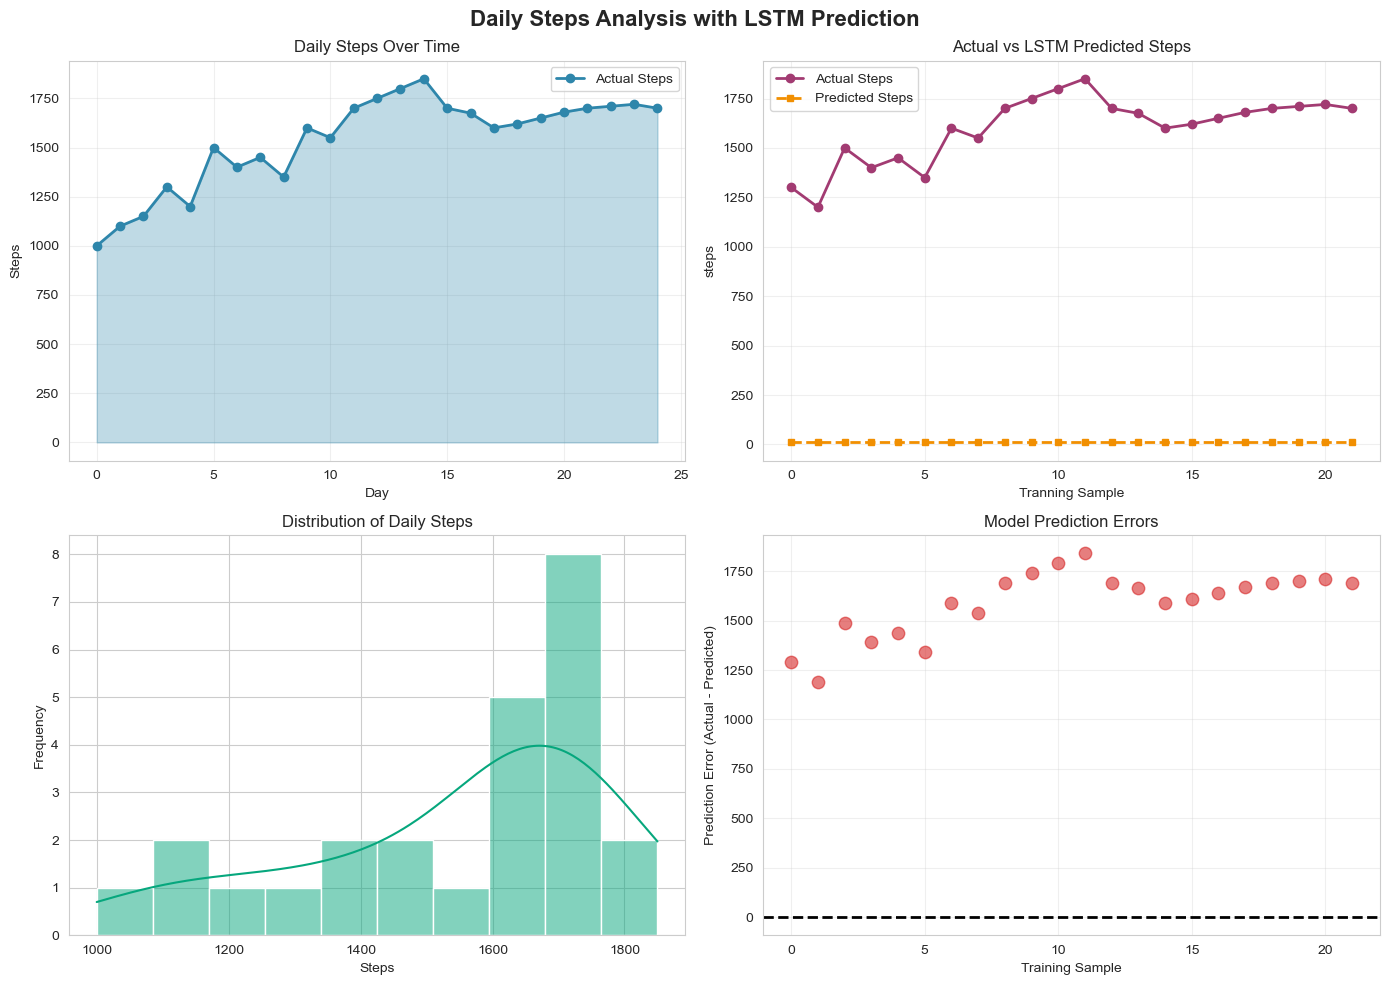


STEPS DATA SUMMARY
Average daily steps: 1538
Min steps: 1000
Max steps: 1850
Standard deviation: 234

Prediction for tomorrow: 10 steps


In [27]:
# 4. Teach our brain!
model.fit(x,y, epochs=50, batch_size=3)     # Watch the story 50 times, 3 pieces each time

# 5. Use our brain to guess tomorrow
tomorrow = model.predict(x[-1].reshape(1, look_back, 1))
print("Tomorrow's steps might be:", int(tomorrow[0][0]))

# 6. Get predictions for all training data to visualize
all_predictions = model.predict(x)

# 7. Create beautiful visualizations
fig, axes = plt.subplots(2,2, figsize=(14, 10))
fig.suptitle('Daily Steps Analysis with LSTM Prediction', fontsize=16, fontweight='bold')

# Plot 1: Original steps over time
axes[0, 0].plot(df.index, df['steps'], marker='o', linewidth=2, markersize=6, label = 'Actual Steps', color='#2E86AB')
axes[0, 0].fill_between(df.index, df['steps'], alpha=0.3, color ='#2E86AB')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_ylabel('Steps')
axes[0, 0].set_title('Daily Steps Over Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted steps
axes[0, 1].plot(range(len(y)), y, marker='o', linewidth=2, markersize=6, label='Actual Steps', color='#A23B72')
axes[0, 1].plot(range(len(all_predictions)), all_predictions, marker='s', linewidth=2, markersize=5, label='Predicted Steps', color='#F18F01', linestyle='--')
axes[0, 1].set_xlabel('Tranning Sample')
axes[0, 1].set_ylabel('steps')
axes[0, 1].set_title('Actual vs LSTM Predicted Steps')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Distribution of steps using seaborn
sns.histplot(data=df, x='steps', bins=10, kde=True, ax=axes[1, 0], color='#06A77D')
axes[1, 0].set_title('Distribution of Daily Steps')
axes[1, 0].set_xlabel('Steps')
axes[1, 0].set_ylabel('Frequency')

# Plot 4: Prediction error (residuals)
residuals = y - all_predictions.flatten()
axes[1, 1].scatter(range(len(residuals)), residuals, s=80, alpha=0.6, color='#D62828')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Training Sample')
axes[1, 1].set_ylabel('Prediction Error (Actual - Predicted)')
axes[1, 1].set_title('Model Prediction Errors')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("STEPS DATA SUMMARY")
print("="*50)
print(f"Average daily steps: {df['steps'].mean():.0f}")
print(f"Min steps: {df['steps'].min():.0f}")
print(f"Max steps: {df['steps'].max():.0f}")
print(f"Standard deviation: {df['steps'].std():.0f}")
print(f"\nPrediction for tomorrow: {int(tomorrow[0][0])} steps")
print("="*50)


In [36]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [37]:
# 1. Load iris flower data
data = load_iris()
x = data.data          # Flower measurements (sepal, petal lengths/widths)
y = data.target        # 0, 1, 2 (which flower type)

In [44]:
# 2. Split into train and test groups
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [45]:
# 3. Make and train XGBoost model
model = XGBClassifier()
model.fit(x_train, y_train)       # Looks at data to learn patterns for each flower type

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [46]:
# 4. Test it out
pred = model.predict(x_test)
print("Accuraccy:", accuracy_score(y_test, pred))        # Did our guesses match correct

# 5. Show one prediction
print("First test flower predicted as type:", pred[0])    # See which flower we think it is!

Accuraccy: 1.0
First test flower predicted as type: 1


In [47]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load iris flower data
data = load_iris()
X = data.data     # Flower measurements (sepal, petal lengths/widths)
y = data.target   # 0, 1, 2 (which flower type)

# 2. Split into train and test groups
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Make and train XGBoost model
model = XGBClassifier()
model.fit(X_train, y_train)    # Looks at data to learn patterns for each flower type

# 4. Test it out
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))   # Did our guesses match correct answers?

# 5. Show one prediction
print("First test flower predicted as type:", pred[0])   # See which flower we think it is!


Accuracy: 1.0
First test flower predicted as type: 1


In [51]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [54]:
# 1. Make simple fake house data
house_data = pd.DataFrame({
    'size': [50, 60, 80, 100, 120, 150, 170],     # in square meters
    'rooms': [1, 2, 2, 3, 3, 4, 5],              # number of rooms
    'price': [30, 35, 50, 65, 70, 90, 120]       # in lakh rupees
})
x = house_data[['size', 'rooms']]
y = house_data['price']

In [55]:
# 2. Split into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [56]:
# 3. Build and train XGBoost regressor
reg = XGBRegressor()
reg.fit(x_train, y_train)   # Learn what makes houses more expensive 

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [57]:
# 4. Predict house prices
pred = reg.predict(x_test)
print("Actual Price:", y_test.values)
print("Predicted Price", np.round(pred, 2))

Actual Price: [30 35 90]
Predicted Price [50. 50. 70.]


In [58]:
# 5. See how good we were
mse = mean_squared_error(y_test, pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 341.6786804199219


In [59]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. Make simple fake house data
house_data = pd.DataFrame({
    'size': [50, 60, 80, 100, 120, 150, 170],     # in square meters
    'rooms': [1, 2, 2, 3, 3, 4, 5],              # number of rooms
    'price': [30, 35, 50, 65, 70, 90, 120]       # in lakh rupees
})
X = house_data[['size', 'rooms']]
y = house_data['price']

# 2. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Build and train XGBoost regressor
reg = XGBRegressor()
reg.fit(X_train, y_train)    # Learn what makes houses more expensive

# 4. Predict house prices
pred = reg.predict(X_test)
print("Actual prices:", y_test.values)
print("Predicted prices:", np.round(pred, 2))

# 5. See how good we were
mse = mean_squared_error(y_test, pred)
print("Mean Squared Error:", mse)


Actual prices: [30 35 90]
Predicted prices: [50. 50. 70.]
Mean Squared Error: 341.6786804199219
